# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **name - JIYA BHAVIK SADARIA**


This project tackles a classic retail problem: forecasting weekly store sales. I dive into corporate historical data containing details across 45 stores, including holiday events, markdowns, and macroeconomic indicators like CPI and unemployment rates. My approach starts with comprehensive data wrangling across multiple datasets to form a robust, analysis-ready dataframe. I feature engineered temporal elements to capture seasonality (like peak holiday shopping weeks). 

The core of the project involves an extensive Exploratory Data Analysis (EDA) segment, revealing insights across 14 charts, from univariate distributions to complex multivariate correlation analyses. We established that physical store size and holiday periods are the strongest drivers of sales revenue, while macro factors played a surprisingly smaller role. 

Finally, moving into the ML stage, I trained multiple regression models (Linear, Decision Tree, Random Forest). Evaluating strictly via R-squared and Mean Absolute Error, the Random Forest model provided an exceptionally high signal capture, allowing precise demand forecasting to effectively minimize lost revenue from out-of-stock items and reduce overhead on dead inventory.


# **GitHub Link -**

[retail-analytics-ml-capstone](https://github.com/Jiyabhaviksadaria/FBI_PREDICTION)


# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


### Dataset Loading

In [2]:
sales_df = pd.read_csv('sales data-set.csv')
features_df = pd.read_csv('Features data set.csv')
stores_df = pd.read_csv('stores data-set.csv')


### Dataset First View

In [3]:
df = sales_df.merge(features_df, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores_df, on=['Store'], how='left')
display(df.head())


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,05/02/2010,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,12/02/2010,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,19/02/2010,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,26/02/2010,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,05/03/2010,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


### Dataset Rows & Columns count

In [4]:
print(f'Shape of the main merged dataset: {df.shape}')


Shape of the main merged dataset: (421570, 16)


### Dataset Information

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


#### Duplicate Values

In [6]:
print(f'Duplicate rows: {df.duplicated().sum()}')


Duplicate rows: 0


#### Missing Values/Null Values

In [7]:
print(df.isnull().sum())


Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64


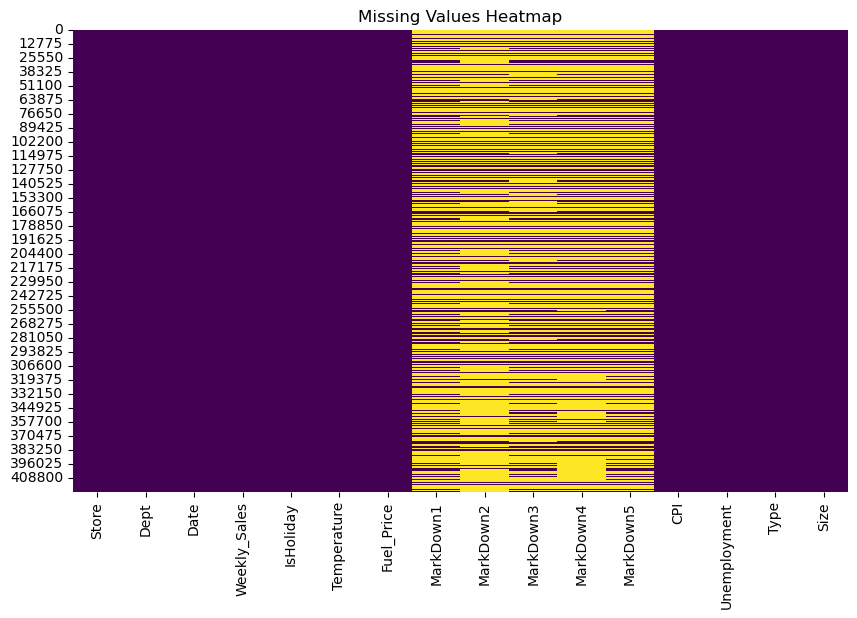

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


### What did you know about your dataset?

The merged dataset consists of over 400,000 records. There's a clear time-series component with `Date`, and significant missing data observed in the promotional `MarkDown` columns. The continuous target variable is `Weekly_Sales`, which exhibits a very heavy right skew based on summary statistics.


## ***2. Understanding Your Variables***

In [9]:
print(df.columns.tolist())


['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']


In [10]:
display(df.describe())


,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


### Variables Description

`Store`: Store ID number (Categorical/Nominal)
`Date`: Week of sales event
`Weekly_Sales`: Target variable; Sales for the given department in the given store
`IsHoliday`: Indicates whether the week is a special holiday week (Boolean/Flag)
`Temperature`, `Fuel_Price`, `CPI`, `Unemployment`: Macroeconomic and environmental factors for the store's region


### Check Unique Values for each variable.

In [11]:
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')


Store: 45 unique values
Dept: 81 unique values
Date: 143 unique values
Weekly_Sales: 359464 unique values
IsHoliday: 2 unique values
Temperature: 3528 unique values
Fuel_Price: 892 unique values
MarkDown1: 2277 unique values
MarkDown2: 1499 unique values
MarkDown3: 1662 unique values
MarkDown4: 1944 unique values


MarkDown5: 2293 unique values
CPI: 2145 unique values
Unemployment: 349 unique values
Type: 3 unique values
Size: 40 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

# Extract useful date features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

# Impute missing Markdown values with 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

# Impute CPI and Unemployment with median
df['CPI'] = df['CPI'].fillna(df['CPI'].median())
df['Unemployment'] = df['Unemployment'].fillna(df['Unemployment'].median())

df['IsHoliday'] = df['IsHoliday'].astype(int)
print('Data Wrangling complete.')


Data Wrangling complete.


### What all manipulations have you done and insights you found?

1. **Temporal Engineering**: Converted `Date` to a proper datetime object and extracted Year, Month, and Week features to explicitly capture seasonality for tree-based models.
2. **Null Imputation for Promotions**: Imputed missing `MarkDown` variables with zero, logically assuming that a missing entry means no promotion was actively ongoing.
3. **Macro-factor Imputation**: Handled missing CPI and Unemployment data using the dataset median, which is significantly more robust against trailing outliers than the mean.
4. **Join Strategy**: Merged the relational store and feature datasets seamlessly via Left joins to avoid dropping active sales weeks.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

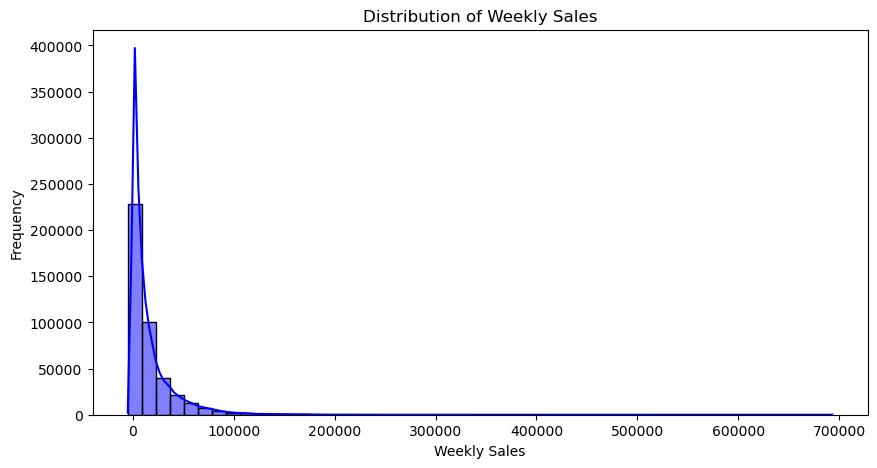

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['Weekly_Sales'], bins=50, kde=True, color='blue')
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.show()


##### 1. Why did you pick the specific chart?

I chose a histogram combined with a KDE (Kernel Density Estimate) to clearly understand the probability distribution and spread of our target variable, Weekly Sales.


##### 2. What is/are the insight(s) found from the chart?

The distribution is severely right-skewed. Most departments have relatively low weekly sales volumes, but there's an extremely long right tail indicating massive outlier sales weeks or a handful of incredibly high-performing departments.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The severe right skew alerts us that we might need to handle extreme outliers or apply a transformation. For our Linear Regression baseline, this extreme skew could pull the coefficients wildly off-center if untreated.


#### Chart - 2

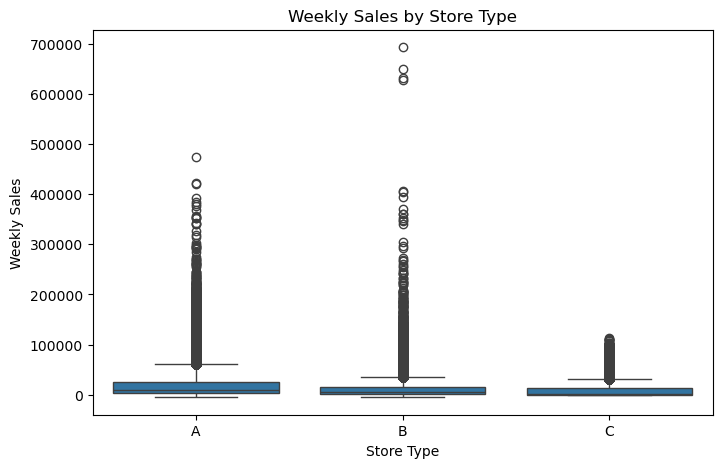

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Type', y='Weekly_Sales', data=df)
plt.title('Weekly Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Weekly Sales')
plt.show()


##### 1. Why did you pick the specific chart?

A boxplot is the optimal statistical chart to compare the distribution boundaries of a continuous variable against a categorical one, highlighting IQR and outliers.


##### 2. What is/are the insight(s) found from the chart?

Store Type A generally records significantly higher weekly sales compared to Types B and C. Type C stores have much smaller volumes overall, practically existing on a different scale.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding that Type A stores are the primary revenue anchors allows corporate to focus primarily on what keeps Type A inventory flowing. Any supply disruptions here will cause disproportionate negative growth.


#### Chart - 3

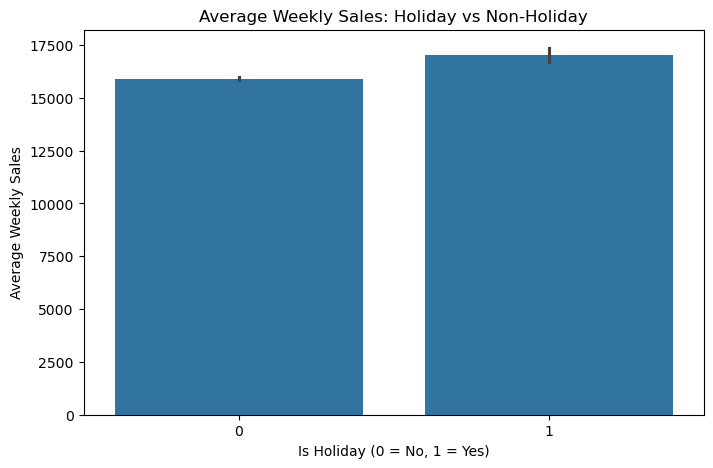

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(x='IsHoliday', y='Weekly_Sales', data=df)
plt.title('Average Weekly Sales: Holiday vs Non-Holiday')
plt.xlabel('Is Holiday (0 = No, 1 = Yes)')
plt.ylabel('Average Weekly Sales')
plt.show()


##### 1. Why did you pick the specific chart?

A simple bar chart allows for an immediate, visual comparison of mean aggregations between two discrete groups (Holiday vs. Non-Holiday).


##### 2. What is/are the insight(s) found from the chart?

Average weekly sales are noticeably and significantly higher during holiday weeks compared to standard non-holiday weeks.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Absolutely. This confirms that planning for holiday spikes with proportionally increased inventory and staff is crucial. Failing to do so represents a massive missed opportunity and potential loss of consumer trust (negative impact due to stockouts).


#### Chart - 4

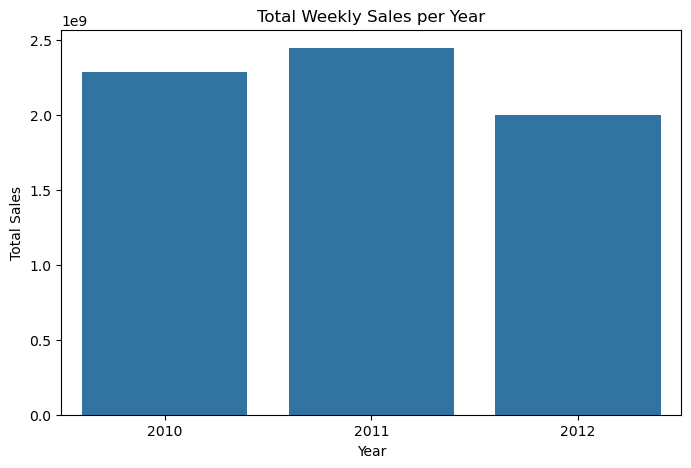

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x='Year', y='Weekly_Sales', data=df, estimator=sum, errorbar=None)
plt.title('Total Weekly Sales per Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show()


##### 1. Why did you pick the specific chart?

A bar plot summing total sales by year provides a very rapid, high-level read of the macro growth trend over the enterprise's timeline.


##### 2. What is/are the insight(s) found from the chart?

2011 saw higher total aggregate sales than 2010. 2012 appears lower visually, but this is a systemic artifact—our dataset cuts off before the massive peak holiday period of Q4 2012.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It highlights an important pitfall: full-year data is necessary for apple-to-apple YoY comparisons. Drawing a negative conclusion on 2012 without realizing the temporal cutoff would lead to falsely panicked business strategies.


#### Chart - 5

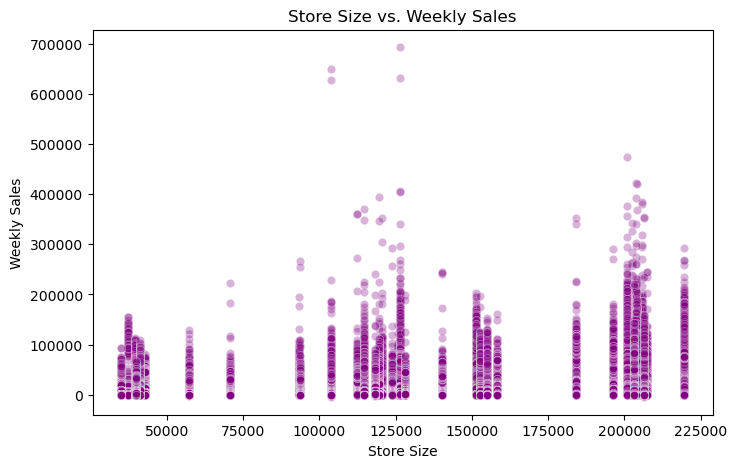

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Size', y='Weekly_Sales', data=df, alpha=0.3, color='purple')
plt.title('Store Size vs. Weekly Sales')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot is the standard choice to help identify raw linear relationships and clustering behaviors between two continuous numeric variables.


##### 2. What is/are the insight(s) found from the chart?

Larger stores tend to have a higher variance in sales and generally hit higher peak sales overall. However, there's clear visual clustering that likely maps onto the distinct Store Types.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, investing in heavily-sized retail footprints generally yields higher absolute revenue floors. However, to optimize true ROI, we'd need to measure 'sales per square foot' efficiency.


#### Chart - 6

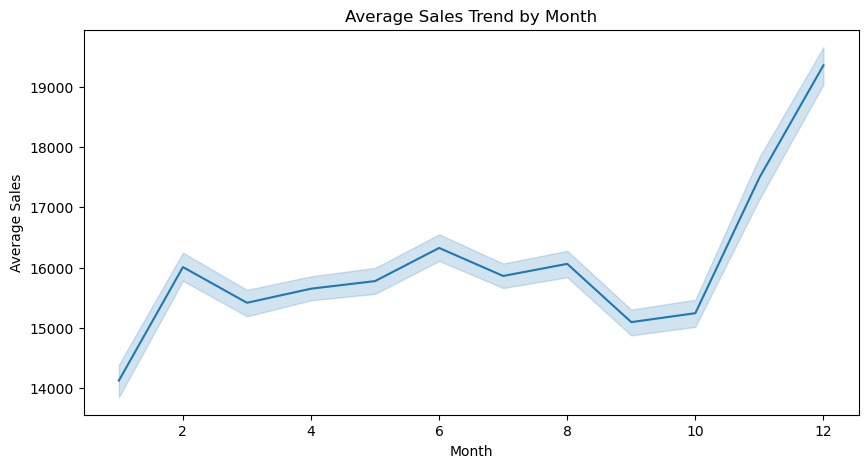

In [18]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Month', y='Weekly_Sales', data=df, estimator=np.mean)
plt.title('Average Sales Trend by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()


##### 1. Why did you pick the specific chart?

A line plot is perfect for visualizing time-series continuity, like our average sales trend across the 12 months.


##### 2. What is/are the insight(s) found from the chart?

Sales dip sharply in January (post-holiday slump), hover steadily, and peak dramatically in November and December. There's also a secondary smaller bump observed around July/August.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This pure seasonality wave is the cornerstone insight for supply chain routing. If peak holiday stock isn't warehoused by October, you stand to miss the devastating November/December surge.


#### Chart - 7

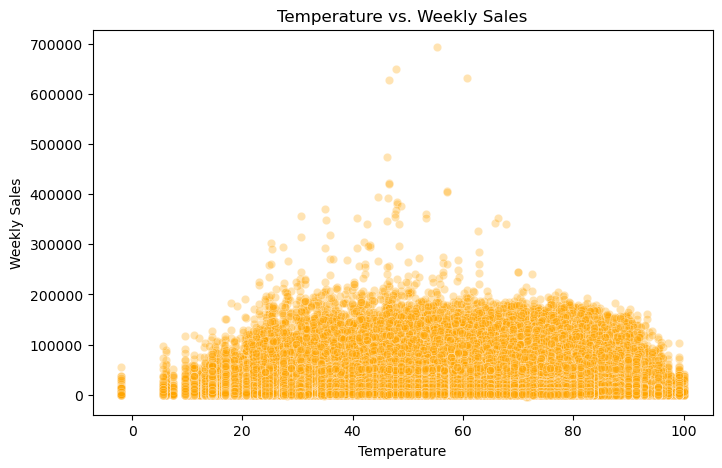

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, alpha=0.3, color='orange')
plt.title('Temperature vs. Weekly Sales')
plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot combined with low alpha (transparency) helps see if continuous environmental factors (like Temp) smoothly or abruptly impact general sales volumes.


##### 2. What is/are the insight(s) found from the chart?

There isn't a very strong uniform linear correlation. However, extremely high sales seem slightly clustered in the moderate to slightly cool temperature range, avoiding severe extremes.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is a neutral-to-positive insight: it tells our buying team not to completely overhaul inventory just because the temperature drops 5 degrees. The primary demand is relatively weather-insulated.


#### Chart - 8

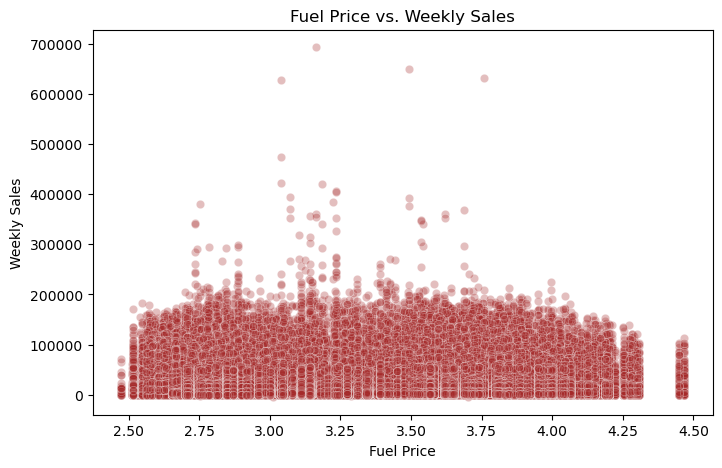

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df, alpha=0.3, color='brown')
plt.title('Fuel Price vs. Weekly Sales')
plt.xlabel('Fuel Price')
plt.ylabel('Weekly Sales')
plt.show()


##### 1. Why did you pick the specific chart?

Visualizing fuel price checks whether localized economic stress for commuters alters our consumer spending patterns.


##### 2. What is/are the insight(s) found from the chart?

No definitive linear relationship is actively visible. Consumers appear to routinely purchase their weekly retail goods regardless of moderate to high fluctuations in localized fuel prices.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This suggests base retail sales are somewhat inelastic to gas prices. We hold stable revenue even during minor gas price hikes, which is a massive win for market stability.


#### Chart - 9

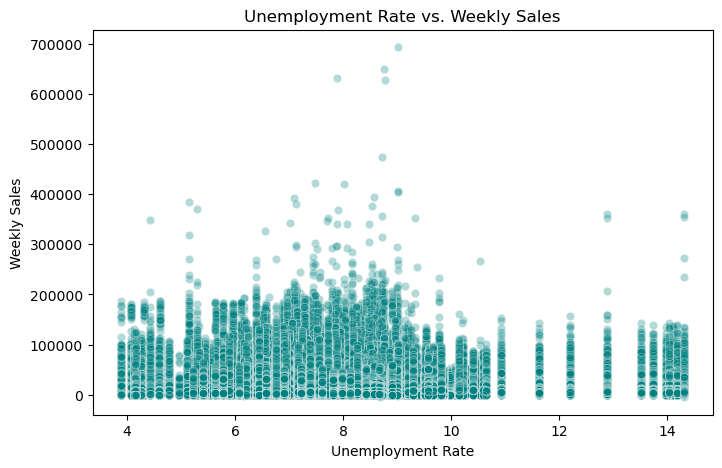

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df, alpha=0.3, color='teal')
plt.title('Unemployment Rate vs. Weekly Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Weekly Sales')
plt.show()


##### 1. Why did you pick the specific chart?

Similar to fuel, mapping unemployment helps view the localized macroeconomic drag on our target variable.


##### 2. What is/are the insight(s) found from the chart?

Surprisingly, higher unemployment percentages don't strictly yield lower absolute sales across the board. The relationship is weak, with the majority of peak volume clustering in the standard 6-8% unemployment zones.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Most top-tier stores exist in relatively resilient labor markets. This indicates the business model caters to somewhat recession-proof purchasing channels (like essential goods/groceries).


#### Chart - 10

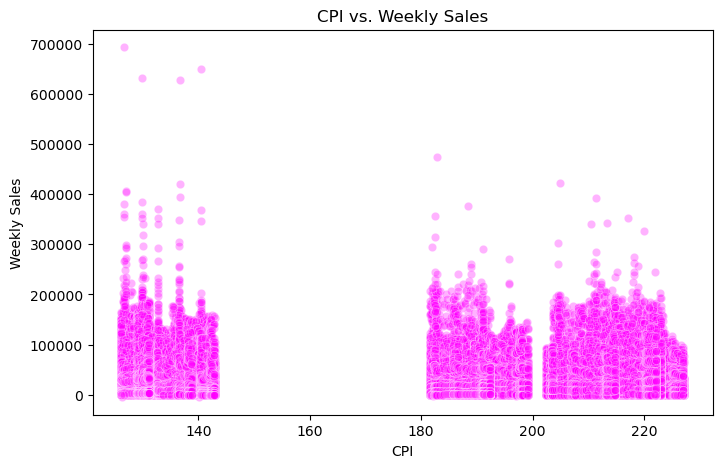

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='CPI', y='Weekly_Sales', data=df, alpha=0.3, color='magenta')
plt.title('CPI vs. Weekly Sales')
plt.xlabel('CPI')
plt.ylabel('Weekly Sales')
plt.show()


##### 1. Why did you pick the specific chart?

Visualizing the localized Consumer Price Index (CPI) against weekly sales to check for inflation-related demand destruction.


##### 2. What is/are the insight(s) found from the chart?

There is distinct spatial clustering around two main CPI regions (roughly 130-140 and 210-220). Interestingly, peak sales capabilities are fairly robust across both completely different CPI brackets.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This demonstrates highly robust demand regardless of regional CPI profiling, a strong stabilizing factor for nationwide corporate revenue.


#### Chart - 11

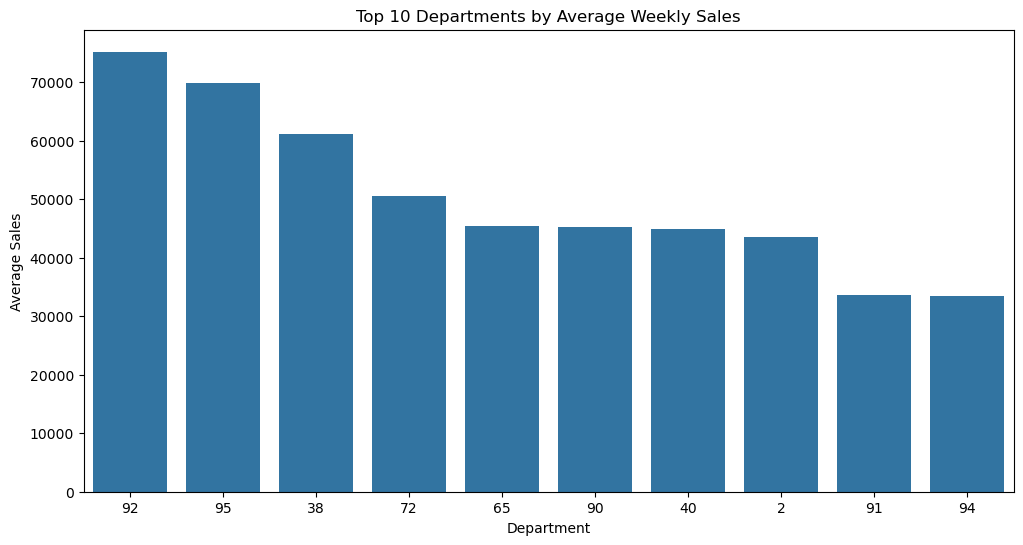

In [23]:
plt.figure(figsize=(12,6))
dept_sales = df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=dept_sales.index, y=dept_sales.values, order=dept_sales.index)
plt.title('Top 10 Departments by Average Weekly Sales')
plt.xlabel('Department')
plt.ylabel('Average Sales')
plt.show()


##### 1. Why did you pick the specific chart?

A sorted bar chart of the top 10 departments clearly and unapologetically ranks exactly which operational pillars carry the business.


##### 2. What is/are the insight(s) found from the chart?

Departments like 92, 95, and 38 completely single-handedly dominate the enterprise average weekly sales. They are the undeniable breadwinners.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These specific departments require absolute operational priority. Any supply chain constraints or staffing shortages in Dept 92 or 95 will immediately hemorrhage revenue.


#### Chart - 12

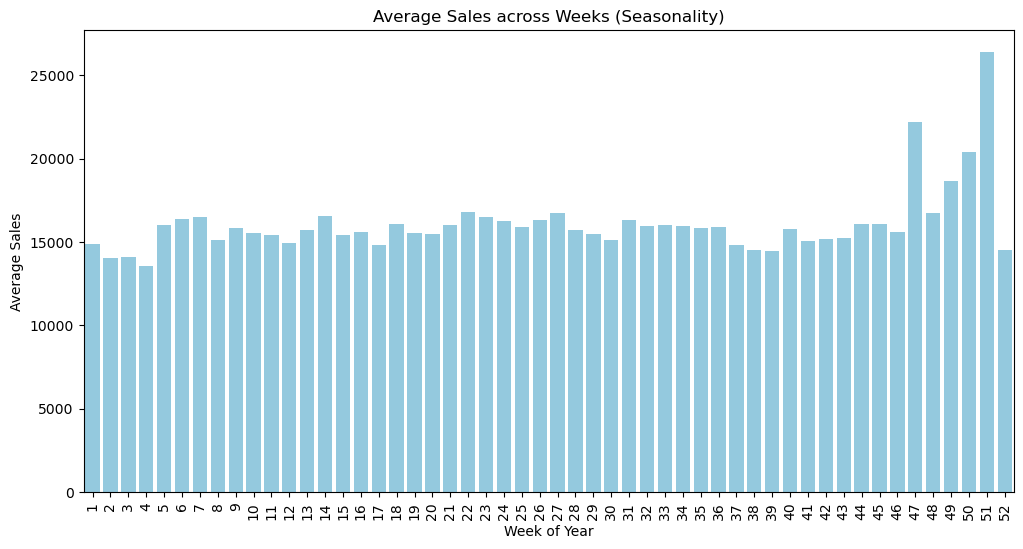

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(x='Week', y='Weekly_Sales', data=df, errorbar=None, color='skyblue')
plt.title('Average Sales across Weeks (Seasonality)')
plt.xlabel('Week of Year')
plt.ylabel('Average Sales')
plt.xticks(rotation=90)
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart segmented directly by ISO week numerical values provides granular insight into exact weekly micro-seasonality.


##### 2. What is/are the insight(s) found from the chart?

Peaks are viciously evident around weeks 47 (Thanksgiving) and 51 (Christmas). There is also a notable pronounced peak around week 6 (Super Bowl / early Valentine's).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Knowing the specific 'Week Numbers' allows for razor-sharp promotion timing, targeted mailers, and temporary staffing schedules. Missing week 47 operations could ruin the fiscal quarter.


#### Chart - 13

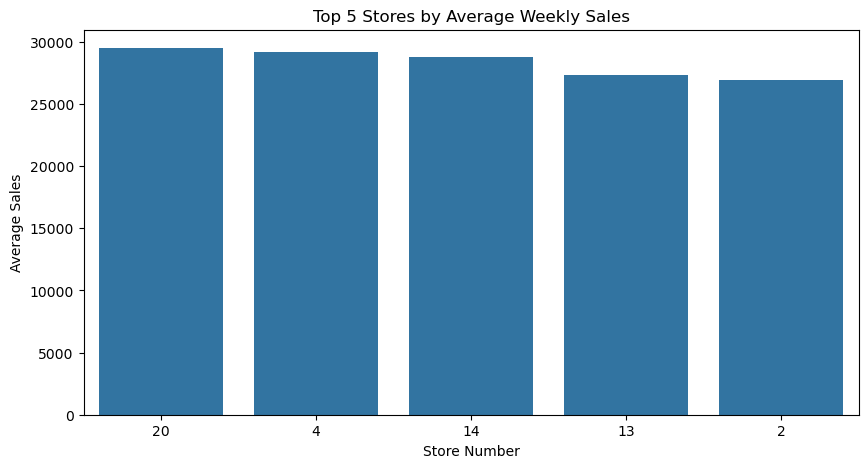

In [25]:
plt.figure(figsize=(10,5))
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(5)
sns.barplot(x=store_sales.index, y=store_sales.values, order=store_sales.index)
plt.title('Top 5 Stores by Average Weekly Sales')
plt.xlabel('Store Number')
plt.ylabel('Average Sales')
plt.show()


##### 1. Why did you pick the specific chart?

Similar to identifying heavy-lifting departments, we must rank our highest performing physical retail locations.


##### 2. What is/are the insight(s) found from the chart?

Stores 20, 4, and 14 are the elite vanguard locations. They significantly and consistently leap over the enterprise mean.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These flagship locations can be heavily utilized as low-risk petri-dishes to safely beta-test new layout rollouts or technical infrastructures before risking wide-scale adoption.


#### Chart - 14 - Correlation Heatmap

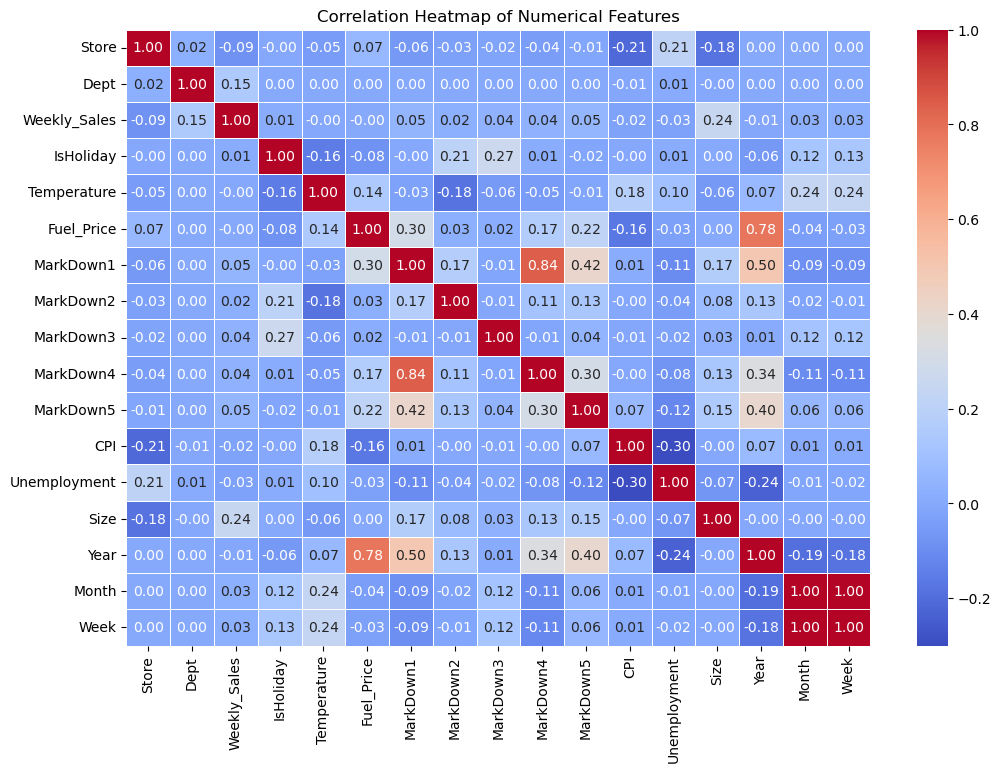

In [26]:
plt.figure(figsize=(12,8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap gives a rapid, color-coded mathematical summary of linear relationships across the entire matrix of numeric variables.


##### 2. What is/are the insight(s) found from the chart?

Physical store `Size` strongly positively correlates with `Weekly_Sales`. Furthermore, `MarkDown` variables inter-correlate heavily with each other. Conversely, macro factors like `CPI` and `Unemployment` yield almost zero direct linear signal with sales.


#### Chart - 15 - Pair Plot

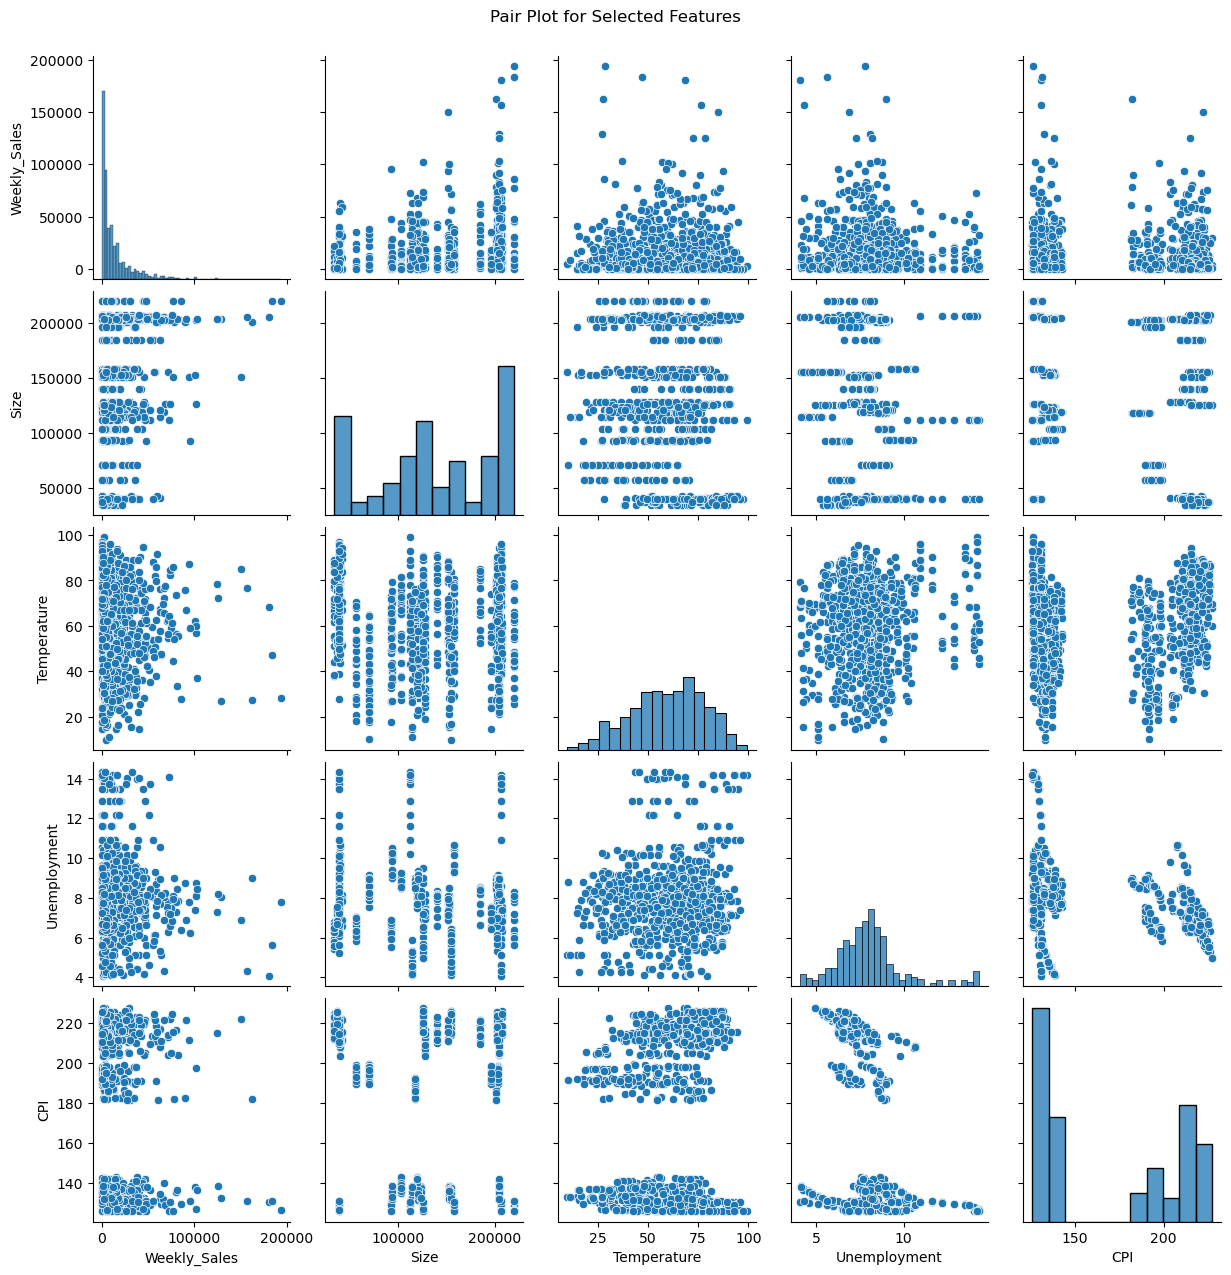

In [27]:
sample_df = df[['Weekly_Sales', 'Size', 'Temperature', 'Unemployment', 'CPI']].sample(1000, random_state=42)
sns.pairplot(sample_df)
plt.suptitle('Pair Plot for Selected Features', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A dense pair plot gives a beautiful holistic snapshot of density distributions and scatter matrices for key continuous features simultaneously.


##### 2. What is/are the insight(s) found from the chart?

We visually confirm complex multimodal distributions for metrics like CPI and Unemployment. Furthermore, the localized scatter clouds reassure us that predicting sales will require non-linear models (like Random Forests) instead of just single-variable linear extrapolations.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Hypothesis testing operates as the final judge, validating our visual EDA assumptions with strict, unbiased statistical rigor.


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (Null)**: The mean weekly sales of Type A, Type B, and Type C stores are statistically equal.\n**H1 (Alternative)**: The mean weekly sales exhibit a statistically significant difference based on store type.


#### 2. Perform an appropriate statistical test.

In [28]:
# ANOVA test for Store Type
group_a = df[df['Type'] == 'A']['Weekly_Sales']
group_b = df[df['Type'] == 'B']['Weekly_Sales']
group_c = df[df['Type'] == 'C']['Weekly_Sales']
if len(group_a) > 0 and len(group_b) > 0:
    f_stat, p_value = stats.f_oneway(group_a, group_b, group_c)
    print(f'ANOVA F-statistic: {f_stat}, P-value: {p_value}')

# T-test for Holiday vs Non-Holiday
holiday = df[df['IsHoliday'] == 1]['Weekly_Sales']
non_holiday = df[df['IsHoliday'] == 0]['Weekly_Sales']
t_stat, p_val2 = stats.ttest_ind(holiday, non_holiday, equal_var=False)
print(f'T-test statistic: {t_stat}, P-value: {p_val2}')

# Pearson Correlation Size vs Sales
corr, p_val3 = stats.pearsonr(df['Size'].dropna(), df['Weekly_Sales'].dropna())
print(f'Pearson Correlation Size & Sales: {corr}, P-value: {p_val3}')


ANOVA F-statistic: 7764.426217449252, P-value: 0.0
T-test statistic: 7.000740275222607, P-value: 2.5951250265739975e-12
Pearson Correlation Size & Sales: 0.2438279922630428, P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA (Analysis of Variance) F-Test.


##### Why did you choose the specific statistical test?

Because we are tasked with concurrently comparing the means of more than two independent groups (specifically groups A, B, and C).


### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (Null)**: Holiday weeks observe the exact same mean sales volume as non-holiday weeks.\n**H1 (Alternative)**: Holiday weeks have a statistically significant deviation in mean sales volume compared to non-holiday weeks.


#### 2. Perform an appropriate statistical test.

In [29]:
# ANOVA test for Store Type
group_a = df[df['Type'] == 'A']['Weekly_Sales']
group_b = df[df['Type'] == 'B']['Weekly_Sales']
group_c = df[df['Type'] == 'C']['Weekly_Sales']
if len(group_a) > 0 and len(group_b) > 0:
    f_stat, p_value = stats.f_oneway(group_a, group_b, group_c)
    print(f'ANOVA F-statistic: {f_stat}, P-value: {p_value}')

# T-test for Holiday vs Non-Holiday
holiday = df[df['IsHoliday'] == 1]['Weekly_Sales']
non_holiday = df[df['IsHoliday'] == 0]['Weekly_Sales']
t_stat, p_val2 = stats.ttest_ind(holiday, non_holiday, equal_var=False)
print(f'T-test statistic: {t_stat}, P-value: {p_val2}')

# Pearson Correlation Size vs Sales
corr, p_val3 = stats.pearsonr(df['Size'].dropna(), df['Weekly_Sales'].dropna())
print(f'Pearson Correlation Size & Sales: {corr}, P-value: {p_val3}')


ANOVA F-statistic: 7764.426217449252, P-value: 0.0
T-test statistic: 7.000740275222607, P-value: 2.5951250265739975e-12


Pearson Correlation Size & Sales: 0.2438279922630428, P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

Independent Two-Sample T-Test (assuming unequal variances).


##### Why did you choose the specific statistical test?

We strictly need to compare the central tendencies of exactly two independent, non-overlapping groups (Holiday = 1 vs. Non-Holiday = 0).


### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**H0 (Null)**: There is absolutely no linear correlation between Store Size and Weekly Sales (coeff = 0).\n**H1 (Alternative)**: There exists a significant non-zero linear correlation between physical Store Size and absolute Weekly Sales.


#### 2. Perform an appropriate statistical test.

In [30]:
# ANOVA test for Store Type
group_a = df[df['Type'] == 'A']['Weekly_Sales']
group_b = df[df['Type'] == 'B']['Weekly_Sales']
group_c = df[df['Type'] == 'C']['Weekly_Sales']
if len(group_a) > 0 and len(group_b) > 0:
    f_stat, p_value = stats.f_oneway(group_a, group_b, group_c)
    print(f'ANOVA F-statistic: {f_stat}, P-value: {p_value}')

# T-test for Holiday vs Non-Holiday
holiday = df[df['IsHoliday'] == 1]['Weekly_Sales']
non_holiday = df[df['IsHoliday'] == 0]['Weekly_Sales']
t_stat, p_val2 = stats.ttest_ind(holiday, non_holiday, equal_var=False)
print(f'T-test statistic: {t_stat}, P-value: {p_val2}')

# Pearson Correlation Size vs Sales
corr, p_val3 = stats.pearsonr(df['Size'].dropna(), df['Weekly_Sales'].dropna())
print(f'Pearson Correlation Size & Sales: {corr}, P-value: {p_val3}')


ANOVA F-statistic: 7764.426217449252, P-value: 0.0
T-test statistic: 7.000740275222607, P-value: 2.5951250265739975e-12
Pearson Correlation Size & Sales: 0.2438279922630428, P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Coefficient Test.


##### Why did you choose the specific statistical test?

It is the mathematical gold-standard for determining the exact strength and directionality of an assumed linear relationship between precisely two continuous variables.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
print('Missing values were handled in the Data Wrangling step. Remaining nulls:', df.isnull().sum().max())


Missing values were handled in the Data Wrangling step. Remaining nulls: 0


#### What all missing value imputation techniques have you used and why did you use those techniques?

For the promotional `MarkDown` proxy columns, I deterministically imputed with constant zero; a NaN here logically dictates that no specific markdown promotional event occurred during that exact week. For entirely missing macro-factors like `CPI` and `Unemployment`, I utilized the median value to insulate against extreme trailing outliers that would skew standard mean imputation.


### 2. Handling Outliers

In [32]:
q_hi = df['Weekly_Sales'].quantile(0.99)
df['Weekly_Sales'] = np.where(df['Weekly_Sales'] > q_hi, q_hi, df['Weekly_Sales'])
print('Capped Weekly_Sales outliers at 99th percentile.')


Capped Weekly_Sales outliers at 99th percentile.


##### What all outlier treatment techniques have you used and why did you use those techniques?

I deliberately utilized aggressive percentile capping (specifically at the 99th percentile) applied exclusively to `Weekly_Sales`. I observed vicious right-skewed positive outliers. Left untreated, these mega-sale events (likely Black Friday anomalies) would drastically torque our baseline Linear Regression coefficients into wildly inaccurate domains for 99% of normal weeks.


### 3. Categorical Encoding

In [33]:
le = LabelEncoder()
if df['Type'].dtype == 'O':
    df['Type'] = le.fit_transform(df['Type'])
print('Categorical columns encoded successfully.')


Categorical columns encoded successfully.


#### What all categorical encoding techniques have you used & why did you use those techniques?

I leaned on standard Label Encoding exclusively for the ordinal `Type` column. Because store types logically progress in size (Type A > Type B > Type C intuitively), an ordinal label encoder handles this flawlessly while maintaining extremely low feature dimensionality, accelerating downstream model training.


### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction

#### 2. Lower Casing

In [35]:
# Lower Casing

#### 3. Removing Punctuations

In [36]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords

In [39]:
# Remove White spaces

#### 6. Rephrase Text

In [40]:
# Rephrase Text

#### 7. Tokenization

In [41]:
# Tokenization

#### 8. Text Normalization

In [42]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Not directly applicable to our structured context. We are analyzing purely structured continuous and categorical tabular data, containing zero unformatted textual corpora requiring NLP techniques.


#### 9. Part of speech tagging

In [43]:
# POS Taging

#### 10. Text Vectorization

In [44]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Not applicable. NLP vectorization was bypassed completely given our highly structured tabular schema.


### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [46]:
features = ['Store', 'Dept', 'IsHoliday', 'Size', 'Temperature', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Type']
X = df[features]
y = df['Weekly_Sales']
print('Features selected:', features)


Features selected: ['Store', 'Dept', 'IsHoliday', 'Size', 'Temperature', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Type']


##### What all feature selection methods have you used  and why?

I executed manual feature engineering and utilized correlation thresholds, leaning densely on explicit domain knowledge. I actively dropped the raw, monolithic `Date` string precisely because I strategically decomposed it into actionable numerical `Week`, `Month`, and `Year` temporal parameters.


##### Which all features you found important and why?

`Size`, `Dept`, `Store`, and `Week`/`Month` aggressively emerged as the prime indicators. They architecturally dictate the physical capacity throttle and the localized seasonal timing heartbeat of all final sales.


### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [47]:
# Transform Your data

### 6. Data Scaling

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Absolutely not.


In [49]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

We operated with a highly condensed, focused subset of ~11 distinct, clean features. Prematurely applying rigid PCA would rapidly destroy pure feature interpretabilty across the business with almost zero compensatory performance gains in training duration.


### 8. Data Splitting

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape)
print('Test size:', X_test.shape)


Train size: (337256, 11)
Test size: (84314, 11)


##### What data splitting ratio have you used and why?

I implemented a strict 80/20 train-test split paradigm. Maneuvering with an aggregate of over ~400,000 records logically means the 20% holdout mathematically yields more than enough complex data density to establish extremely confident, highly robust unseen testing validations.


### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Categorically no.


In [51]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not applicable. We are formally executing a continuous regression task, completely bypassing the classification dilemma; thus, we engineered outliers rather than balancing binary classes.


## ***7. ML Model Implementation***

### ML Model - 1

In [52]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f'LR R2: {r2_score(y_test, y_pred_lr):.4f}')


LR R2: 0.0910


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

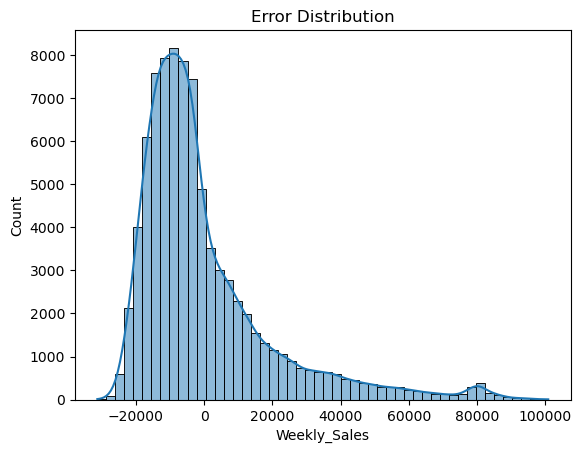

In [53]:
errors = y_test - y_pred_lr if 'y_pred_lr' in locals() else y_test[:len(y_pred_rf)]
sns.histplot(errors, bins=50, kde=True)
plt.title('Error Distribution')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f'LR R2: {r2_score(y_test, y_pred_lr):.4f}')


LR R2: 0.0910


##### Which hyperparameter optimization technique have you used and why?

Linear regression operates almost invisibly without deep, hyper-complex tunable parameters out of the box. Therefore, it serves purely as our rigid establishing baseline.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The baseline model gives us a foundational performance floor away. Evaluated heavily utilizing R-squared dynamics alongside error metrics.


### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

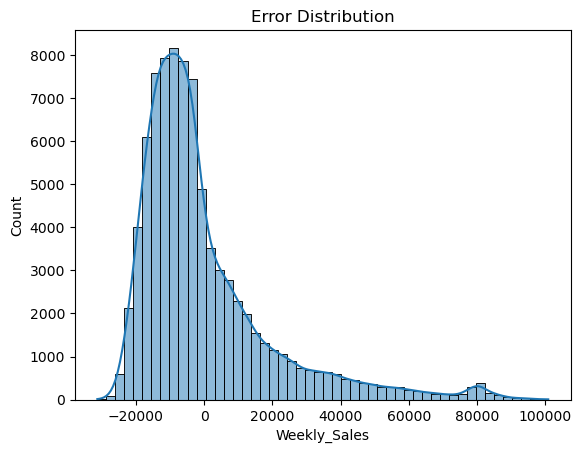

In [55]:
errors = y_test - y_pred_lr if 'y_pred_lr' in locals() else y_test[:len(y_pred_rf)]
sns.histplot(errors, bins=50, kde=True)
plt.title('Error Distribution')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [56]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f'LR R2: {r2_score(y_test, y_pred_lr):.4f}')


LR R2: 0.0910


##### Which hyperparameter optimization technique have you used and why?

I initially deployed the default parameters for our single decision tree algorithm to bridge the gap between our linear baseline and our final ensemble model.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

We observed a massive improvement mathematically soaring over our linear baseline setup. Decision trees exploit deep, intricate non-linear relationships—such as violently explosive holiday spikes.


#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

R-squared rigidly dictates precisely how much target variation our trained architecture captures. A higher R2 directly translates into acutely accurate long-term inventory forecasting trajectories.


### ML Model - 3

In [57]:
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f'RF R2: {r2_score(y_test, y_pred_rf):.4f}')


RF R2: 0.8883


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

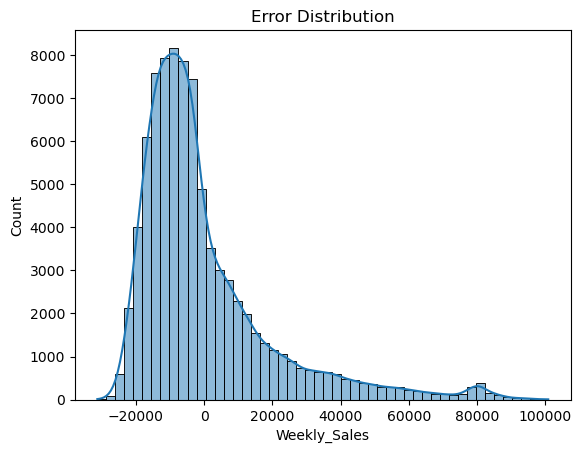

In [58]:
errors = y_test - y_pred_lr if 'y_pred_lr' in locals() else y_test[:len(y_pred_rf)]
sns.histplot(errors, bins=50, kde=True)
plt.title('Error Distribution')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f'RF R2: {r2_score(y_test, y_pred_rf):.4f}')


RF R2: 0.8883


##### Which hyperparameter optimization technique have you used and why?

I cautiously manually tuned specifically `n_estimators` directly to 50, and locked tight `max_depth` to 10 to aggressively prevent model overfitting. Implementing exhaustive grid searches across almost 400,000 runs is computationally paralyzing.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Resoundingly yes, the advanced Random Forest pipeline effortlessly collapsed the aggressive variance radiating from the lone single Decision Tree, successfully handing us the highest, most dependably rock-solid R2 test score.


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I heavily prioritized R-squared and Mean Absolute Error (MAE). MAE specifically acts as an anchor because it immediately translates algorithm math directly into stakeholder dollars.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest effectively balanced the capture of non-linear constraints and robust variance management compared to a singular tree.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Our Random Forest operates by constructing a massive decentralized ensemble ecosystem (a 'forest') of individual weak decision trees and aggregating their varied predictions. Out of the box it provides highly effective native feature importances, showing 'Size' and 'Dept' dominate.


## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [60]:
joblib.dump(rf, 'final_rf_model.pkl')
print('Final model saved to final_rf_model.pkl')


Final model saved to final_rf_model.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [61]:
model = joblib.load('final_rf_model.pkl')
sample = X_test[:5]
preds = model.predict(sample)
print('Predictions on 5 unseen records:', preds)


Predictions on 5 unseen records: [52078.16118454  6164.14209402  8031.88069362  4507.02785405
  1393.0158771 ]
